In [1]:
# import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (cross_val_score, 
                                    cross_validate, 
                                    GridSearchCV,
                                    RandomizedSearchCV,
                                    TimeSeriesSplit)
from sklearn.metrics import (accuracy_score, 
                            roc_auc_score, 
                            roc_curve, 
                            precision_recall_curve, 
                            average_precision_score, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay, 
                            RocCurveDisplay)
import joblib
from pathlib import Path

from load_data import load_data
from feature_engineering import build_features
from baseline_evaluation import run_baseline_eval
from predict_model import get_latest_stats, predict_any_matchup

print("All imports completed.")

All imports completed.


In [2]:
df = load_data()
df.head()

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,203.0,605.0,-525.0,9.0,0.0,1.0,1.0,0.0,2.0,0.0
1,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,163.0,421.0,-903.0,-28.0,2.0,4.0,2.0,1.0,5.0,1.0
2,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,187.0,-149.0,-224.0,-5.0,1.0,3.0,0.0,3.0,4.0,3.0
3,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,284.0,-1288.0,-2005.0,-85.0,2.0,1.0,2.0,3.0,4.0,0.0
4,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,27.0,499.0,-314.0,12.0,1.0,3.0,2.0,0.0,7.0,2.0


In [3]:
df.tail()

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
597559,LOLTMNT01_409089,complete,NaN,Asia Master,2026,NaN,0,2026-06-21 11:38:09,4,16.11,...,251.0,-742.0,-1523.0,-22.0,4.0,3.0,2.0,4.0,5.0,1.0
597560,LOLTMNT01_409089,complete,NaN,Asia Master,2026,NaN,0,2026-06-21 11:38:09,4,16.11,...,285.0,-2775.0,-1957.0,-41.0,0.0,3.0,3.0,3.0,5.0,2.0
597561,LOLTMNT01_409089,complete,NaN,Asia Master,2026,NaN,0,2026-06-21 11:38:09,4,16.11,...,41.0,-482.0,-516.0,-8.0,1.0,3.0,2.0,0.0,8.0,2.0
597562,LOLTMNT01_409089,complete,NaN,Asia Master,2026,NaN,0,2026-06-21 11:38:09,4,16.11,...,936.0,6334.0,5953.0,87.0,12.0,27.0,7.0,7.0,14.0,12.0
597563,LOLTMNT01_409089,complete,NaN,Asia Master,2026,NaN,0,2026-06-21 11:38:09,4,16.11,...,1023.0,-6334.0,-5953.0,-87.0,7.0,14.0,12.0,12.0,27.0,7.0


In [4]:
print("----- DATA OVERVIEW -----")
print(f"{len(df.columns)} features")
# rows including 5 players and 1 team stats for each team
print(f"{len(df):,} total rows")
# one match has 2 teams occupying 2 rows
print(f"{len(df[df['position'] == 'team']):,} team rows (approx. {len(df[df['position'] == 'team']) // 2:,} total matches)")
print(f"Dating {pd.to_datetime(df['date']).dt.date.min()} to {pd.to_datetime(df['date']).dt.date.max()}")


----- DATA OVERVIEW -----
165 features
597,564 total rows
99,594 team rows (approx. 49,797 total matches)
Dating 2022-01-10 to 2026-06-21


In [ ]:
df_teams = df[df['position'] == 'team'].copy()

all_leagues = df_teams['league'].unique()

first_league = all_leagues[0]
complete_columns = set(df_teams[df_teams['league'] == first_league].dropna(axis=1, how='any').columns)

for league in all_leagues[1:]:
    league_clean_cols = set(df_teams[df_teams['league'] == league].dropna(axis=1, how='any').columns)
    complete_columns = complete_columns.intersection(league_clean_cols)

universally_safe_features = sorted(list(complete_columns))

print(f" ----- UNIVERSALLY COMPLETE ATTRIBUTES ({len(universally_safe_features)} out of {len(df.columns)} found) -----\n")
for index, col in enumerate(universally_safe_features):
    print(f"Index {index}: {col}")


 ----- UNIVERSALLY COMPLETE ATTRIBUTES (27 out of 165 found) -----

Index 0: assists
Index 1: barons
Index 2: ckpm
Index 3: datacompleteness
Index 4: date
Index 5: deaths
Index 6: dragons
Index 7: game
Index 8: gameid
Index 9: gamelength
Index 10: kills
Index 11: league
Index 12: opp_barons
Index 13: opp_dragons
Index 14: opp_towers
Index 15: participantid
Index 16: playoffs
Index 17: position
Index 18: result
Index 19: side
Index 20: team kpm
Index 21: teamdeaths
Index 22: teamkills
Index 23: teamname
Index 24: totalgold
Index 25: towers
Index 26: year


In [ ]:
# debug code snippet
# team_counts = df[df['position'] == 'team'].groupby('gameid').size()
# malformed_games = team_counts[team_counts != 2]

# print(f"Number of games broken in raw data (missing a side): {len(malformed_games)}")
# print("Sample broken game IDs:", malformed_games.index.tolist()[:5])


Number of games broken in raw data (missing a side): 0
Sample broken game IDs: []


In [7]:
# data processing and feature engineering
df_processed = build_features(df_teams)
display(df_processed.head())
print(f"Matches: {len(df_processed):,}")


,gameid,date,league,teamname_blue,blue_win,elo_blue,last_5_winrate_blue,last_5_gold_per_min_blue,last_5_dragons_blue,last_5_barons_blue,...,gold_per_min_delta,dragons_delta,barons_delta,towers_delta,kills_delta,assists_delta,elo_delta,opp_elo_delta,ckpm_delta,deaths_delta
0,8401-8401_game_2,2022-01-10 10:09:22,LPL,Oh My God,1,1516.00,1.0,33.309890,2.0,1.0,...,5.076923,1.0,1.0,5.0,7.0,24.0,32.00,0.0,0.0000,7.0
1,8402-8402_game_2,2022-01-10 12:18:24,LPL,FunPlus Phoenix,0,1516.00,1.0,33.814580,4.0,2.0,...,5.726889,3.0,2.0,7.0,4.0,15.0,32.00,0.0,0.0000,4.0
2,8402-8402_game_3,2022-01-10 13:17:30,LPL,Royal Never Give Up,0,1501.47,0.5,29.941908,2.5,0.5,...,-1.568420,0.5,-1.0,-1.0,4.5,8.0,2.94,16.0,0.0000,4.5
3,NA1_4170926184,2022-01-11 00:46:15,PGC,Glaive Esports Prime,0,1516.00,1.0,34.400284,3.0,1.0,...,-0.804639,0.0,0.0,-3.0,25.0,50.0,0.00,0.0,0.9528,-16.0
4,NA1_4170806914,2022-01-11 00:47:14,PGC,Golden Guardians Academy,1,1516.00,1.0,36.026232,2.0,0.0,...,6.936369,-1.0,-1.0,1.0,8.0,1.0,0.00,0.0,0.6746,1.0


Matches: 48,802


In [8]:
print("Null values in each column:")
df_processed.isnull().sum()

Null values in each column:


gameid                      0
date                        0
league                      0
teamname_blue               0
blue_win                    0
elo_blue                    0
last_5_winrate_blue         0
last_5_gold_per_min_blue    0
last_5_dragons_blue         0
last_5_barons_blue          0
last_5_towers_blue          0
last_5_kills_blue           0
last_5_deaths_blue          0
last_5_assists_blue         0
last_5_ckpm_blue            0
last_5_opp_elo_blue         0
teamname_red                0
elo_red                     0
last_5_winrate_red          0
last_5_gold_per_min_red     0
last_5_dragons_red          0
last_5_barons_red           0
last_5_towers_red           0
last_5_kills_red            0
last_5_deaths_red           0
last_5_assists_red          0
last_5_ckpm_red             0
last_5_opp_elo_red          0
winrate_delta               0
gold_per_min_delta          0
dragons_delta               0
barons_delta                0
towers_delta                0
kills_delt

In [9]:
print(f"Duplicate rows found: {df_processed.duplicated().sum()}")

Duplicate rows found: 0


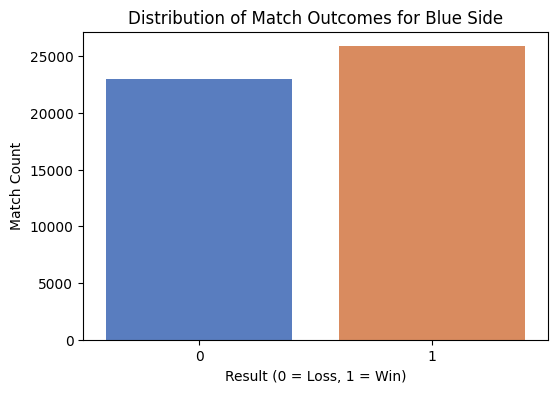

In [ ]:
# visualize target
plt.figure(figsize=(6, 4))
sns.countplot(data=df_processed, x='blue_win', hue='blue_win', palette='muted', legend=False)
plt.title('Distribution of Match Outcomes for Blue Side')
plt.xlabel('Result (0 = Loss, 1 = Win)')
plt.ylabel('Match Count')
plt.show()

Healthy dataset. No severe class imbalance.

In [11]:
delta_features = [
    'winrate_delta',
    'gold_per_min_delta',
    'dragons_delta',
    'barons_delta',
    'towers_delta',
    'kills_delta',
    'deaths_delta',
    'assists_delta',
    'ckpm_delta',
    'opp_elo_delta',
    'elo_delta']

# training sample
scaler = StandardScaler()
split_idx = int(len(df_processed) * 0.80)
df_train = df_processed.iloc[:split_idx]
df_test = df_processed.iloc[split_idx:]
X_train, y_train = df_train[delta_features], df_train['blue_win']
X_test, y_test = df_test[delta_features], df_test['blue_win']

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# double checking the training set
print(X_train.columns.tolist())
print(X_train.shape)
print(df_processed['league'].value_counts())
print()


['winrate_delta', 'gold_per_min_delta', 'dragons_delta', 'barons_delta', 'towers_delta', 'kills_delta', 'deaths_delta', 'assists_delta', 'ckpm_delta', 'opp_elo_delta', 'elo_delta']
(39041, 11)
league
LPL      3505
LCK      2334
LDL      2331
LCKC     2279
NACL     1734
         ... 
EBLPA      42
ASI        42
LTA        40
CCWS       39
LCL        12
Name: count, Length: 83, dtype: int64



In [12]:
run_baseline_eval(X_train, y_train)

Majority class baseline: 0.53
Elo-only AUC: 0.68

Model                       Accuracy    ROC-AUC   F1-Score
──────────────────────────────────────────────────────────
Logistic Regression            0.642      0.697      0.669
Random Forest                  0.626      0.671      0.648
XGBoost                        0.614      0.660      0.641

Best baseline model: Logistic Regression (ROC-AUC = 0.697)



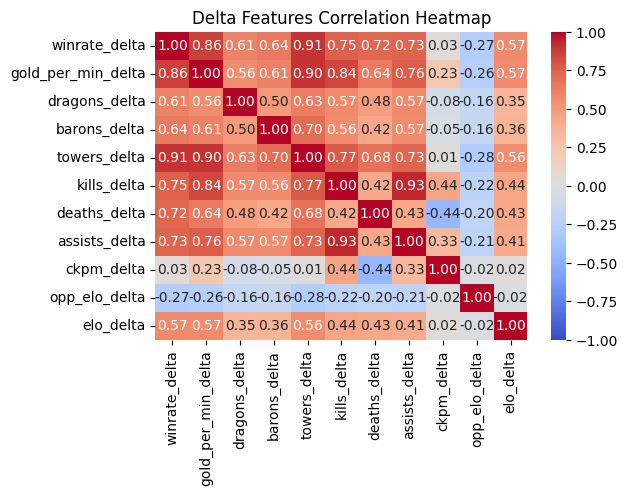

In [13]:
corr_matrix = df_processed[delta_features].corr()

# visual heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Delta Features Correlation Heatmap")
plt.show()

`towers_delta` and `assists_delta` are above 0.90 correlation with other features -> might be redundant.

In [14]:
# try dropping heavily correlated features 
delta_features_v2 = [
    'winrate_delta',
    'gold_per_min_delta',
    'dragons_delta',
    'barons_delta',
    'kills_delta',
    'deaths_delta',
    'ckpm_delta',
    'opp_elo_delta',
    'elo_delta']

X_train, y_train = df_train[delta_features_v2], df_train['blue_win']
X_test, y_test = df_test[delta_features_v2], df_test['blue_win']

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# double checking the training set
print(X_train.columns.tolist())
print(X_train.shape)
print(df_processed['league'].value_counts())



['winrate_delta', 'gold_per_min_delta', 'dragons_delta', 'barons_delta', 'kills_delta', 'deaths_delta', 'ckpm_delta', 'opp_elo_delta', 'elo_delta']
(39041, 9)
league
LPL      3505
LCK      2334
LDL      2331
LCKC     2279
NACL     1734
         ... 
EBLPA      42
ASI        42
LTA        40
CCWS       39
LCL        12
Name: count, Length: 83, dtype: int64


In [15]:
run_baseline_eval(X_train, y_train)

Majority class baseline: 0.53
Elo-only AUC: 0.68

Model                       Accuracy    ROC-AUC   F1-Score
──────────────────────────────────────────────────────────
Logistic Regression            0.642      0.697      0.669
Random Forest                  0.624      0.670      0.647
XGBoost                        0.614      0.660      0.640

Best baseline model: Logistic Regression (ROC-AUC = 0.697)



Dropping those features removes redundant data without degrading model's performance.

In [16]:
SEED = 42

# GridSearchCV
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000, random_state=SEED),
    param_grid=lr_param_grid, 
    cv=TimeSeriesSplit(n_splits=3), 
    scoring='roc_auc',
    n_jobs=-1)

grid_search.fit(X_train[delta_features_v2], y_train)
best_tuned_lr = grid_search.best_estimator_
print(f"Optimal Parameters: {grid_search.best_params_}\n")

test_auc = grid_search.score(X_test[delta_features_v2], y_test)
print("----- FINAL TUNED MODEL PERFORMANCE -----")
print(f"Final ROC-AUC: {test_auc:.3f}")


# Define a broad but efficient parameter search grid for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 150, 200],           # Number of gradient boosted trees
    'max_depth': [3, 4, 5, 6],                    # Maximum tree depth (3-5 is ideal for tabular data)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # Step size shrinkage to prevent overfitting
    'subsample': [0.7, 0.8, 1.0],              # Subsample ratio of the training instances
    'colsample_bytree': [0.7, 0.8, 1.0],       # Subsample ratio of columns when constructing each tree
    'min_child_weight': [1, 3, 5]              # Minimum sum of instance weight needed in a child
}

# Use RandomizedSearchCV to efficiently search the grid
xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=SEED, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=15,                                 # Number of random parameter settings sampled (keeps it fast)
    cv=TimeSeriesSplit(n_splits=3),            # Keeping your exact validation strategy
    scoring='roc_auc',
    n_jobs=-1,
    random_state=SEED
)

# Fit the random search pipeline
xgb_random_search.fit(X_train[delta_features_v2], y_train)
best_tuned_xgb = xgb_random_search.best_estimator_

print("----- XGBOOST TUNING RESULTS -----")
print(f"Optimal Parameters: {xgb_random_search.best_params_}\n")

# Evaluate performance on the test set
xgb_test_auc = xgb_random_search.score(X_test[delta_features_v2], y_test)
print("----- FINAL TUNED XGBOOST PERFORMANCE -----")
print(f"Final ROC-AUC: {xgb_test_auc:.3f}")



Optimal Parameters: {'C': 0.1, 'solver': 'saga'}

----- FINAL TUNED MODEL PERFORMANCE -----
Final ROC-AUC: 0.697
----- XGBOOST TUNING RESULTS -----
Optimal Parameters: {'subsample': 0.8, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

----- FINAL TUNED XGBOOST PERFORMANCE -----
Final ROC-AUC: 0.695


           Feature  Importance (Coefficient)  Absolute_Importance
gold_per_min_delta                     0.730                0.730
         elo_delta                     0.521                0.521
        ckpm_delta                    -0.208                0.208
      barons_delta                    -0.139                0.139
      deaths_delta                    -0.130                0.130
     opp_elo_delta                     0.125                0.125
     winrate_delta                    -0.097                0.097
       kills_delta                    -0.046                0.046
     dragons_delta                    -0.013                0.013


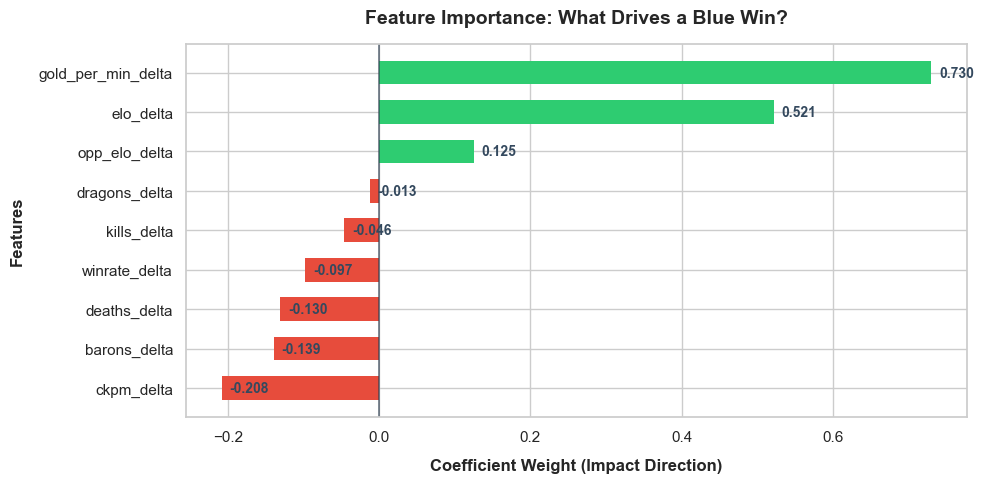

In [17]:
best_model = LogisticRegression(C=0.1, solver='saga', random_state=42)
best_model.fit(X_train, y_train)

# extract coefficients
importance = best_model.coef_[0]

# 3. Create a clean DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance (Coefficient)': importance,
    'Absolute_Importance': np.abs(importance)}).sort_values(by='Absolute_Importance', ascending=False)

print(feature_importance_df.round(3).to_string(index=False))

# 1. Sort the dataframe correctly for visualization
plot_df = feature_importance_df.sort_values(by='Importance (Coefficient)', ascending=True)

# 2. Set up a clean, modern aesthetic
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# 3. Create a dynamic color palette (Green for positive impact, Red for negative)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in plot_df['Importance (Coefficient)']]

# 4. Plot the horizontal bar chart
bars = plt.barh(plot_df['Feature'], plot_df['Importance (Coefficient)'], color=colors, edgecolor='none', height=0.6)

# 5. Clean up axes and add a center baseline
plt.axvline(x=0, color='#2c3e50', linestyle='-', linewidth=1.2, alpha=0.7)
plt.xlabel('Coefficient Weight (Impact Direction)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Features', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Feature Importance: What Drives a Blue Win?', fontsize=14, fontweight='bold', pad=15)

# 6. Add exact value labels to the end of each bar for quick scanning
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01, 
        bar.get_y() + bar.get_height()/2, 
        f'{width:.3f}', 
        va='center', 
        ha='left',
        fontsize=10, 
        fontweight='bold',
        color='#34495e'
    )

plt.tight_layout()
plt.show()

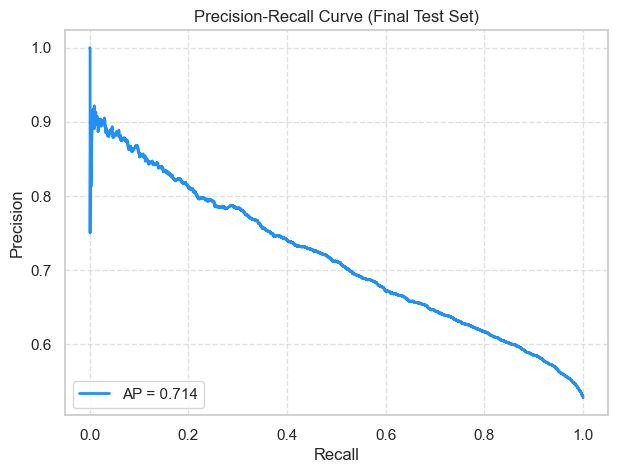

In [18]:
y_scores = best_model.predict_proba(X_test[delta_features_v2])[:, 1]

# calculate precision and recall thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'AP = {avg_precision:.3f}', color='dodgerblue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Final Test Set)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

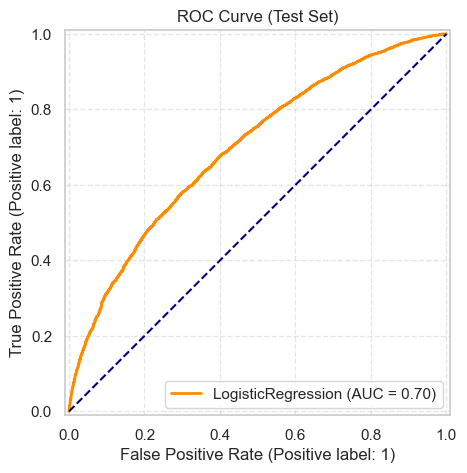

In [19]:

# 1. Get prediction probabilities and hard class predictions
y_probs = best_model.predict_proba(X_test[delta_features_v2])[:, 1]
y_pred = best_model.predict(X_test[delta_features_v2])

# 2. Setup a clean side-by-side plot layout
fig, ax = plt.subplots(figsize=(14, 5))

RocCurveDisplay.from_estimator(
    best_model, X_test[delta_features_v2], y_test, 
    color="darkorange", lw=2, ax=ax
)
ax.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--") # Random guess baseline
ax.set_title("ROC Curve (Test Set)")
ax.grid(True, linestyle="--", alpha=0.5)


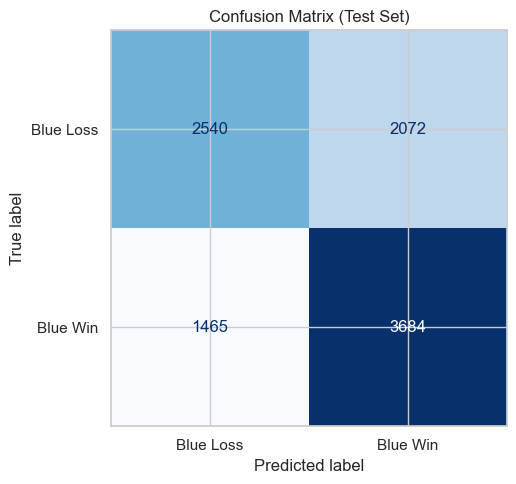

In [20]:
cm = confusion_matrix(y_test, y_pred)
# Labels match your target: 0 = Blue Loss (Red Win), 1 = Blue Win
fig, ax = plt.subplots(figsize=(14, 5))

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Blue Loss", "Blue Win"]
)
cm_display.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix (Test Set)")

plt.tight_layout()
plt.show()


Target Threshold found: 0.6636
If you only predict a Blue Win when the model is 66.4% sure:


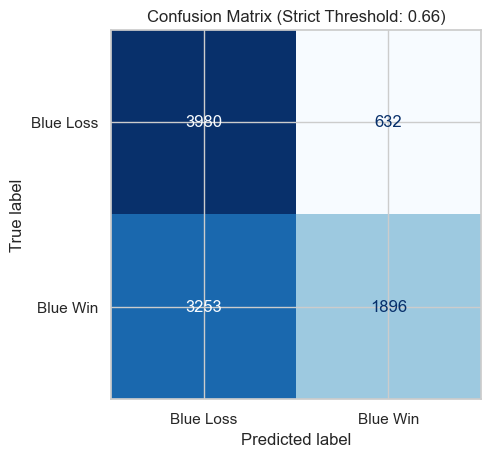

In [21]:
y_probs = best_model.predict_proba(X_test[delta_features_v2])[:, 1]

# 2. Get all precisions and their matching thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# 3. Find the first threshold where precision crosses 80% (0.80)
idx = np.where(precisions >= 0.75)[0][0]
target_threshold = thresholds[idx]

print(f"Target Threshold found: {target_threshold:.4f}")
print(f"If you only predict a Blue Win when the model is {target_threshold*100:.1f}% sure:")

# 4. Apply the new threshold to generate strict predictions
y_pred_strict = (y_probs >= target_threshold).astype(int)

# 5. Display the new high-precision Confusion Matrix
cm_strict = confusion_matrix(y_test, y_pred_strict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_strict, display_labels=["Blue Loss", "Blue Win"])
disp.plot(cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Confusion Matrix (Strict Threshold: {target_threshold:.2f})")
plt.show()

In [22]:
df_processed[df_processed['league'].isin(['LCK', 'LPL'])]['teamname_blue'].unique()

array(['Oh My God', 'FunPlus Phoenix', 'Royal Never Give Up', 'JD Gaming',
       "Anyone's Legend", 'LGD Gaming', 'Kiwoom DRX', 'Top Esports',
       'DN SOOPers', 'Ultra Prime', 'Hanwha Life Esports',
       'Nongshim RedForce', 'Invictus Gaming', 'Weibo Gaming',
       'KT Rolster', 'Gen.G', 'T1', 'HANJIN BRION', 'ThunderTalk Gaming',
       'Rare Atom', 'Team WE', 'Dplus Kia', 'Victory Five',
       'Bilibili Gaming', 'LNG Esports', 'Liiv SANDBOX', 'EDward Gaming',
       'Ninjas in Pyjamas', 'BNK FEARX'], dtype=object)

In [23]:
team_blue_stats = get_latest_stats("Bilibili Gaming", df_processed)
team_red_stats = get_latest_stats("T1", df_processed)

prediction = predict_any_matchup(team_blue_stats, team_red_stats, best_model, X_train, scaler, threshold=0.50)

----- MATCH PREDICTION -----
Blue Side Elo: 1881    | Red Side Elo: 1900   
Last 5 WR: 80.0%       | Last 5 WR: 40.0%
────────────────────────────────────────────────
Probability of Red Side Wins: 55.8%


----- END OF PIPELINE -----

## Post-Mortem: Regional Data Gap

During the testing phase of this project, I discovered a significant data collection asymmetry that inadvertently obmitted **100% of all LPL (Chinese region) matches** from the final training set.

### Reasoning
The dataset architecture was initially built around rolling early-game metrics. While these stats are completely populated across other regions, I did not check thoroughly to realize that LPL data feeds do not report them. Consequently, every LPL match row contained a `NaN` value under those specific columns. Because the feature engineering pipeline concluded with a strict `.dropna()` safety filter, **all 4,282 LPL matches were silently deleted** from the pipeline before the model could ever see them.

### Solution
Rather than filling in missing values with the mean (which is artificially inaccurate), I rewrote the framework.